# Artificial Neural Netwroks 

## Setup 

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics import roc_curve

In [2]:
try:
    X_train = joblib.load("X_train.pkl")
    X_test = joblib.load("X_test.pkl")
    y_train = joblib.load("y_train.pkl")
    y_test = joblib.load("y_test.pkl")
except FileNotFoundError as e:
    print(f"Error: pickle file not found — {e}")
else:
    print("Loaded successfully")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test :", X_test.shape, "y_test :", y_test.shape)

Loaded successfully
X_train: (3996, 42) y_train: (3996,)
X_test : (1000, 42) y_test : (1000,)


## Results Log 
Tracks accuracy at every stage of the notebook (baseline, tuning, cross-validation, etc.) so improvements can be compared side by side rather than only seeing the most recently printed number.

In [3]:
results_log = []

def log_result(name, y_true, y_pred):
    """Log accuracy from a set of predictions."""
    try:
        acc = accuracy_score(y_true, y_pred)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc})
    print(f"[Logged] {name}: {acc:.4f}")
    return acc

def log_value(name, acc):
    """Log an already-computed accuracy value (e.g. a CV mean)."""
    try:
        acc = float(acc)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc})
    print(f"[Logged] {name}: {acc:.4f}")
    return acc

## Baseline Model
An ANN model is developed using arbitrary hyperparameters before applying hyperparameter tuning. This provides a benchmark for comparing the optimized model.

In [4]:
try:
    ann = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    )
    ann.fit(X_train, y_train)
    ann_pred = ann.predict(X_test)
except (ValueError, RuntimeError) as e:
    print(f"Error training baseline ANN model: {e}")
else:
    ann_accuracy = accuracy_score(y_test, ann_pred)
    print("Baseline Accuracy:", ann_accuracy)
    print(classification_report(y_test, ann_pred))
    log_result("Baseline (64,32 hidden layers)", y_test, ann_pred)

Baseline Accuracy: 0.775
              precision    recall  f1-score   support

           0       0.77      0.69      0.73       438
           1       0.78      0.84      0.81       562

    accuracy                           0.78      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.78      0.77      1000

[Logged] Baseline (64,32 hidden layers): 0.7750


## Hyperparameter Tuning 
Grid Search is used to determine the optimal combination of hyperparameters to improve the predictive performance of the ANN model.

In [5]:
param_grid = {
    "hidden_layer_sizes": [(64, 32)],
    "activation": ["relu"],
    "learning_rate_init": [0.001, 0.002, 0.005],
    "alpha": [0.0001, 0.001],
    "solver": ["adam"],
    "early_stopping": [True, False]
}

try:
    grid_search = GridSearchCV(
        estimator=MLPClassifier(max_iter=3000, random_state=42),
        param_grid=param_grid,
        cv=10,
        scoring="accuracy",
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
except (ValueError, RuntimeError) as e:
    print(f"Error during Grid Search: {e}")
else:
    best_ann = grid_search.best_estimator_
    print("========== Best Hyperparameters ==========")
    print(grid_search.best_params_)
    print("\nBest Cross Validation Accuracy:")
    print(f"{grid_search.best_score_:.4f}")
    log_value("Grid Search (10-fold CV, best score)", grid_search.best_score_)

========== Best Hyperparameters ==========
{'activation': 'relu', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.002, 'solver': 'adam'}

Best Cross Validation Accuracy:
0.8058
[Logged] Grid Search (10-fold CV, best score): 0.8058


## Best Model Evaluation
The optimized ANN model obtained from Grid Search is evaluated on the test set, including a training-vs-testing accuracy comparison to check for overfitting or underfitting.

In [6]:
try:
    best_pred = best_ann.predict(X_test)
    train_accuracy = best_ann.score(X_train, y_train)
    test_accuracy = best_ann.score(X_test, y_test)
except (ValueError, RuntimeError, NameError) as e:
    print(f"Error evaluating best model: {e}")
else:
    print("Training Accuracy:", train_accuracy)
    print("Testing Accuracy:", test_accuracy)
    print()
    print(classification_report(y_test, best_pred))
    log_result("Grid Search Tuned (test set)", y_test, best_pred)

Training Accuracy: 0.8498498498498499
Testing Accuracy: 0.789

              precision    recall  f1-score   support

           0       0.77      0.74      0.76       438
           1       0.81      0.82      0.81       562

    accuracy                           0.79      1000
   macro avg       0.79      0.78      0.78      1000
weighted avg       0.79      0.79      0.79      1000

[Logged] Grid Search Tuned (test set): 0.7890


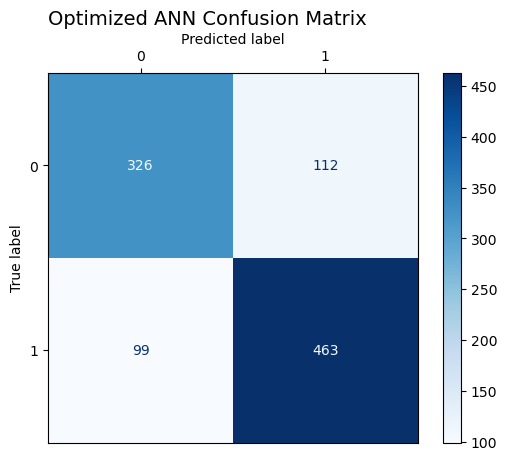

In [15]:
try:
    cm = confusion_matrix(y_test, best_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")

    plt.gca().xaxis.tick_top()
    plt.gca().xaxis.set_label_position("top")
    plt.title("Optimized ANN Confusion Matrix", fontsize=14, loc='left')
    plt.xlabel("Predicted label", fontsize=10)
    plt.ylabel("True label", fontsize=10)

    plt.show()
except (ValueError, NameError) as e:
    print(f"Error plotting confusion matrix: {e}")

## Model Stability (Cross-Validation)
10-fold cross-validation is performed to evaluate the stability and generalization performance of the optimized ANN model.

[0.82       0.82       0.7775     0.835      0.8125     0.805
 0.80451128 0.77944862 0.79949875 0.80451128]
Average CV Accuracy: 0.805796992481203
[Logged] 10-Fold Cross-Validation (mean): 0.8058


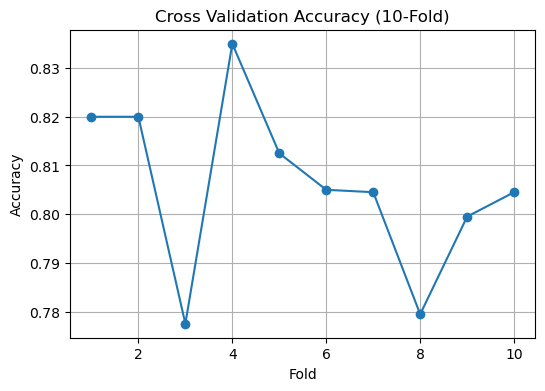

In [8]:
try:
    cv_scores = cross_val_score(best_ann, X_train, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during cross-validation: {e}")
else:
    print(cv_scores)
    print("Average CV Accuracy:", cv_scores.mean())
    log_value("10-Fold Cross-Validation (mean)", cv_scores.mean())

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, 11), cv_scores, marker="o")
    plt.title("Cross Validation Accuracy (10-Fold)")
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.show()

## Youden's J Statistic (Decision Threshold Optimization)

Rather than relying on the default 0.5 probability cutoff, this finds the threshold that maximizes **Youden's J = Sensitivity + Specificity − 1**, using the ROC curve. This is a formula distinct from accuracy/precision/recall/F1, and can improve overall classification accuracy by shifting the decision boundary to better suit the data's true positive/negative trade-off.

In [9]:
try:
    y_probs = best_ann.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    j_scores = tpr - fpr
    best_threshold_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_threshold_idx]
    y_pred_optimal = (y_probs >= best_threshold).astype(int)
except (ValueError, AttributeError, RuntimeError) as e:
    print(f"Error during threshold optimization: {e}")
else:
    print(f"Optimal threshold: {best_threshold:.4f}")
    print(f"Youden's J at this threshold: {j_scores[best_threshold_idx]:.4f}")
    print("\nAccuracy with optimal threshold:", accuracy_score(y_test, y_pred_optimal))
    print(classification_report(y_test, y_pred_optimal))
    log_result("Grid Search + Youden's J", y_test, y_pred_optimal)

Optimal threshold: 0.6768
Youden's J at this threshold: 0.6347

Accuracy with optimal threshold: 0.81
              precision    recall  f1-score   support

           0       0.74      0.88      0.80       438
           1       0.89      0.76      0.82       562

    accuracy                           0.81      1000
   macro avg       0.81      0.82      0.81      1000
weighted avg       0.82      0.81      0.81      1000

[Logged] Grid Search + Youden's J: 0.8100


## L2 Regularization (Weight Decay)
ANN's model-specific \"extra formula\": `alpha`, already searched during Grid Search above, is the coefficient on an **L2 regularization term** added directly to the network's loss function: $$Loss = Original\\_Loss + \\alpha \\sum w^2$$ where the sum runs over every weight in the network. This penalizes large weights, discouraging the network from relying too heavily on any single connection — which reduces overfitting. A larger `alpha` means stronger regularization (simpler, more constrained model); a smaller `alpha` lets the network fit the training data more freely (higher risk of overfitting). \n\nThe cell below makes this concrete by sweeping `alpha` directly and showing its effect on accuracy, using the other best hyperparameters found by Grid Search.

[Logged] L2 Regularization (alpha=1e-05): 0.8036
[Logged] L2 Regularization (alpha=0.0001): 0.8053
[Logged] L2 Regularization (alpha=0.001): 0.8058
[Logged] L2 Regularization (alpha=0.01): 0.7998
[Logged] L2 Regularization (alpha=0.1): 0.8081
[Logged] L2 Regularization (alpha=1.0): 0.7933


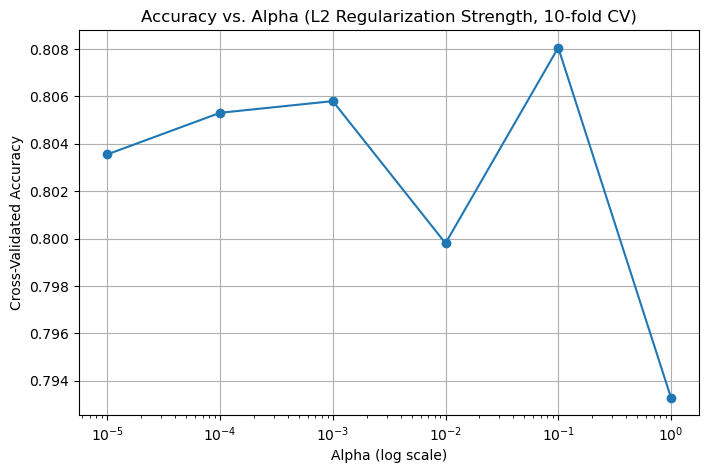

In [10]:
best_params = grid_search.best_params_

alpha_range = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0]
alpha_scores = []

try:
    for a in alpha_range:
        temp_ann = MLPClassifier(
            hidden_layer_sizes=best_params["hidden_layer_sizes"],
            activation=best_params["activation"],
            learning_rate_init=best_params["learning_rate_init"],
            solver=best_params["solver"],
            early_stopping=best_params["early_stopping"],
            alpha=a,
            max_iter=3000,
            random_state=42
        )
        cv_result = cross_val_score(temp_ann, X_train, y_train, cv=10, scoring="accuracy")
        alpha_scores.append(cv_result.mean())
        log_value(f"L2 Regularization (alpha={a})", cv_result.mean())
except (ValueError, RuntimeError) as e:
    print(f"Error during alpha sweep: {e}")
else:
    plt.figure(figsize=(8, 5))
    plt.plot(alpha_range, alpha_scores, marker="o")
    plt.xscale("log")
    plt.title("Accuracy vs. Alpha (L2 Regularization Strength, 10-fold CV)")
    plt.xlabel("Alpha (log scale)")
    plt.ylabel("Cross-Validated Accuracy")
    plt.grid(True)
    plt.show()

## Training Diagnostics (Loss Curve & Convergence)
The loss curve shows how training loss changes during learning — a decreasing curve indicates the ANN is learning and converging properly. The number of iterations and final loss confirm convergence.

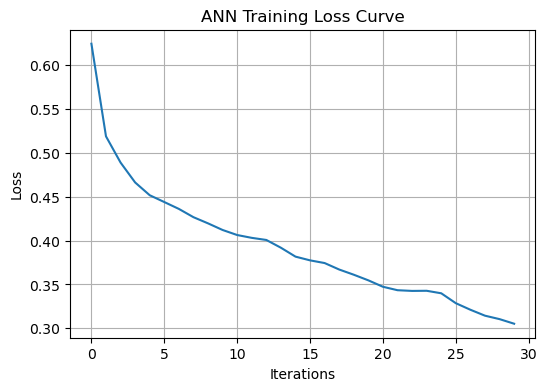

Number of Iterations: 30
Final Loss: 0.30531164774650876


In [11]:
try:
    plt.figure(figsize=(6, 4))
    plt.plot(best_ann.loss_curve_)
    plt.title("ANN Training Loss Curve")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    print("Number of Iterations:", best_ann.n_iter_)
    print("Final Loss:", best_ann.loss_)
except AttributeError as e:
    print(f"Loss curve not available for this solver/model: {e}")

## Result Summary & Save Model

In [12]:
report = classification_report(y_test, best_pred, output_dict=True)

summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Train-Test Gap"],
    "Value": [
        accuracy_score(y_test, best_pred),
        report["weighted avg"]["precision"],
        report["weighted avg"]["recall"],
        report["weighted avg"]["f1-score"],
        train_accuracy - test_accuracy
    ]
})

summary

,Metric,Value
0,Accuracy,0.789000
1,Precision,0.788504
2,Recall,0.789000
3,F1-score,0.788617
4,Train-Test Gap,0.060850


## Full Accuracy Progression Log 
Every stage's accuracy, in the order it was calculated — shows how (or whether) each technique actually improved on the previous stage.

In [13]:
log_df = pd.DataFrame(results_log)
log_df

,Stage,Accuracy
0,"Baseline (64,32 hidden layers)",0.775000
1,"Grid Search (10-fold CV, best score)",0.805797
2,Grid Search Tuned (test set),0.789000
3,10-Fold Cross-Validation (mean),0.805797
4,Grid Search + Youden's J,0.810000
5,L2 Regularization (alpha=1e-05),0.803550
6,L2 Regularization (alpha=0.0001),0.805305
7,L2 Regularization (alpha=0.001),0.805797
8,L2 Regularization (alpha=0.01),0.799799
9,L2 Regularization (alpha=0.1),0.808055


In [14]:
# save the trained model
try:
    joblib.dump(best_ann, 'ann_model.pkl')
except (OSError, PermissionError) as e:
    print(f"Error saving model: {e}")
else:
    print("Model saved successfully!")

Model saved successfully!
